In [1]:
import pickle 
import numpy as np

gt_path = "/home/lucas/repos/PointPillars/sparsepcgc_eval/kitti_infos_val.pkl"
with open(gt_path, 'rb') as file:
        loaded_data = pickle.load(file)


In [2]:
def bbox3d2corners(bboxes):
    '''
    bboxes: shape=(n, 7)
    return: shape=(n, 8, 3)
           ^ z   x            6 ------ 5
           |   /             / |     / |
           |  /             2 -|---- 1 |   
    y      | /              |  |     | | 
    <------|o               | 7 -----| 4
                            |/   o   |/    
                            3 ------ 0 
    x: front, y: left, z: top
    '''
    centers, dims, angles = bboxes[:, :3], bboxes[:, 3:6], bboxes[:, 6]

    # 1.generate bbox corner coordinates, clockwise from minimal point
    bboxes_corners = np.array([[-0.5, -0.5, 0], [-0.5, -0.5, 1.0], [-0.5, 0.5, 1.0], [-0.5, 0.5, 0.0],
                               [0.5, -0.5, 0], [0.5, -0.5, 1.0], [0.5, 0.5, 1.0], [0.5, 0.5, 0.0]], 
                               dtype=np.float32)
    bboxes_corners = bboxes_corners[None, :, :] * dims[:, None, :] # (1, 8, 3) * (n, 1, 3) -> (n, 8, 3)

    # 2. rotate around z axis
    rot_sin, rot_cos = np.sin(angles), np.cos(angles)
    # in fact, -angle
    rot_mat = np.array([[rot_cos, rot_sin, np.zeros_like(rot_cos)],
                        [-rot_sin, rot_cos, np.zeros_like(rot_cos)],
                        [np.zeros_like(rot_cos), np.zeros_like(rot_cos), np.ones_like(rot_cos)]], 
                        dtype=np.float32) # (3, 3, n)
    rot_mat = np.transpose(rot_mat, (2, 1, 0)) # (n, 3, 3)
    bboxes_corners = bboxes_corners @ rot_mat # (n, 8, 3)

    # 3. translate to centers
    bboxes_corners += centers[:, None, :]
    return bboxes_corners

In [3]:

def bbox3d2corners(bboxes):
    '''
    bboxes: shape=(n, 7)
    return: shape=(n, 8, 3)
           ^ z   x            6 ------ 5
           |   /             / |     / |
           |  /             2 -|---- 1 |   
    y      | /              |  |     | | 
    <------|o               | 7 -----| 4
                            |/   o   |/    
                            3 ------ 0 
    x: front, y: left, z: top
    '''
    print(np.shape(bboxes))
    centers, dims, angles = bboxes[:, :3], bboxes[:, 3:6], bboxes[:, 6]

    # 1.generate bbox corner coordinates, clockwise from minimal point
    bboxes_corners = np.array([[-0.5, -0.5, 0], [-0.5, -0.5, 1.0], [-0.5, 0.5, 1.0], [-0.5, 0.5, 0.0],
                               [0.5, -0.5, 0], [0.5, -0.5, 1.0], [0.5, 0.5, 1.0], [0.5, 0.5, 0.0]], 
                               dtype=np.float32)
    bboxes_corners = bboxes_corners[None, :, :] * dims[:, None, :] # (1, 8, 3) * (n, 1, 3) -> (n, 8, 3)

    # 2. rotate around z axis
    rot_sin, rot_cos = np.sin(angles), np.cos(angles)
    # in fact, -angle
    rot_mat = np.array([[rot_cos, rot_sin, np.zeros_like(rot_cos)],
                        [-rot_sin, rot_cos, np.zeros_like(rot_cos)],
                        [np.zeros_like(rot_cos), np.zeros_like(rot_cos), np.ones_like(rot_cos)]], 
                        dtype=np.float32) # (3, 3, n)
    rot_mat = np.transpose(rot_mat, (2, 1, 0)) # (n, 3, 3)
    bboxes_corners = bboxes_corners @ rot_mat # (n, 8, 3)

    # 3. translate to centers
    bboxes_corners += centers[:, None, :]
    return bboxes_corners

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D

def draw_pointcloud_with_boxes(bin_path, boxes_corners_gt, boxes_corners_pred=None, mode="default", show=True):
    """
    Draw a KITTI-format point cloud and overlay two sets of 3D bounding boxes on a single canvas
    with two subplots: a 3D view (left) and a bird's-eye view (BEV, right).

    Parameters
    ----------
    bin_path : str
        Path to the .bin velodyne file (float32, Nx4).
    boxes_corners_gt : array-like
        Ground-truth corners (N_gt,8,3) or list of (8,3) arrays.
    boxes_corners_pred : array-like or None
        Predicted corners (N_pred,8,3) or list of (8,3) arrays. If None, only GT is drawn.
    mode : str
        Unused for now, kept for API compatibility. Set to 'bev' to initialize BEV-friendly view.
    show : bool
        If True (default) call plt.show(); otherwise return (fig, (ax3d, axbev)).

    Returns
    -------
    (fig, (ax3d, axbev))
        Matplotlib figure and axes used for plotting.
    """
    # Load point cloud
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

    fig = plt.figure(figsize=(14, 7))
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    axbev = fig.add_subplot(1, 2, 2)

    ax3d.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.1, c='gray', alpha=0.5)
    axbev.scatter(points[:, 0], points[:, 1], s=0.5, c='gray', alpha=0.4)

    def _as_corners_array(boxes):
        if boxes is None:
            return np.zeros((0, 8, 3), dtype=np.float32)
        arr = np.asarray(boxes)
        if arr.ndim == 3 and arr.shape[1:] == (8, 3):
            return arr
        # assume list-like of (8,3)
        return np.stack(list(boxes), axis=0) if len(boxes) > 0 else np.zeros((0, 8, 3), dtype=np.float32)

    gt = _as_corners_array(boxes_corners_gt)
    pred = _as_corners_array(boxes_corners_pred)

    def draw_box_3d(ax, corners, color='r', linewidth=1.5):
        edges = [
            [0,1],[1,2],[2,3],[3,0],  # bottom
            [4,5],[5,6],[6,7],[7,4],  # top
            [0,4],[1,5],[2,6],[3,7]   # sides
        ]
        for e in edges:
            p0 = corners[e[0]]
            p1 = corners[e[1]]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, linewidth=linewidth)

    def draw_box_bev(ax, corners, color='r', linewidth=1.5):
        # Use bottom face indices 0-3 for BEV
        xy = corners[:, :2]
        edges = [[0,1],[1,2],[2,3],[3,0]]
        for e in edges:
            ax.plot([xy[e[0], 0], xy[e[1], 0]], [xy[e[0], 1], xy[e[1], 1]], color=color, linewidth=linewidth)

    # Draw ground-truth boxes (green)
    for corners in gt:
        draw_box_3d(ax3d, corners, color='tab:green', linewidth=1.8)
        draw_box_bev(axbev, corners, color='tab:green', linewidth=1.8)

    # Draw predicted boxes (red)
    for corners in pred:
        draw_box_3d(ax3d, corners, color='tab:red', linewidth=1.2)
        draw_box_bev(axbev, corners, color='tab:red', linewidth=1.2)

    # Legend (proxy artists)
    legend_elems = [Line2D([0], [0], color='tab:green', lw=2, label='Ground Truth')]
    if pred.shape[0] > 0:
        legend_elems.append(Line2D([0], [0], color='tab:red', lw=2, label='Predicted'))
    axbev.legend(handles=legend_elems)

    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title('3D View')

    axbev.set_xlabel('X')
    axbev.set_ylabel('Y')
    axbev.set_title('Bird\'s-Eye View (BEV)')
    axbev.axis('equal')

    # Tweak views
    if mode == 'bev':
        ax3d.view_init(elev=90, azim=-90)
    else:
        ax3d.view_init(elev=20, azim=-45)

    # Optional: set BEV limits to point cloud extents with small margin
    try:
        xmin, ymin = points[:, 0].min(), points[:, 1].min()
        xmax, ymax = points[:, 0].max(), points[:, 1].max()
        dx, dy = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
        axbev.set_xlim(xmin - dx, xmax + dx)
        axbev.set_ylim(ymin - dy, ymax + dy)
    except Exception:
        pass

    plt.tight_layout()
    if show:
        plt.show()
    return fig, (ax3d, axbev)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


(3, 7)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


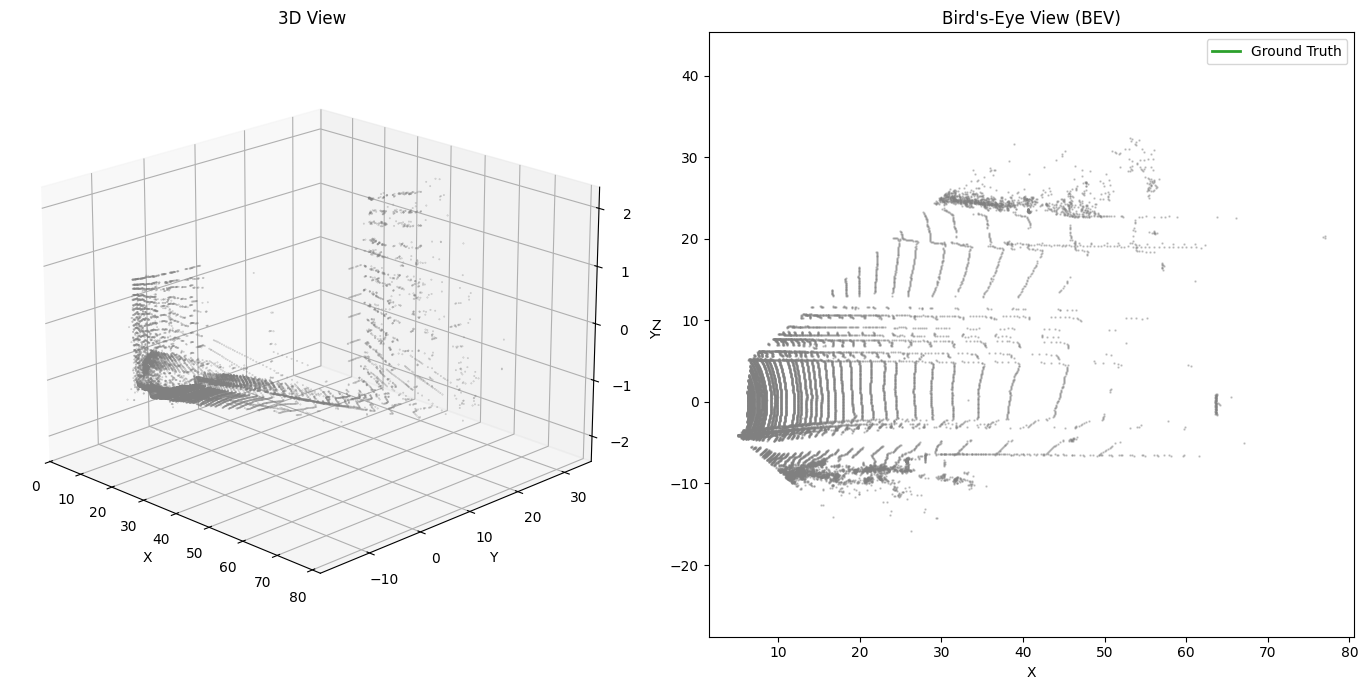

(<Figure size 1400x700 with 2 Axes>,
 (<Axes3D: title={'center': '3D View'}, xlabel='X', ylabel='Y', zlabel='Z'>,
  <Axes: title={'center': "Bird's-Eye View (BEV)"}, xlabel='X', ylabel='Y'>))

In [8]:
import numpy as np

pcd_limit_range = np.array([0, -40, -3, 70.4, 40, 0.0], dtype=np.float32)
# Extract annotation arrays
annos = loaded_data[1]['annos']
locations = annos['location']
dimensions = annos['dimensions']
rotations_y = annos['rotation_y']


# Filter out invalid boxes (e.g., 'DontCare' or negative dimensions)
valid_mask = (annos['name'] != 'DontCare') & (dimensions[:, 0] > 0) & (dimensions[:, 1] > 0) & (dimensions[:, 2] > 0)

locations_valid = locations[valid_mask]
dimensions_valid = dimensions[valid_mask]
rotations_y_valid = rotations_y[valid_mask]

# Compute corners for each valid box
# boxes_corners = [compute_box_corners(loc, dim, ry) for loc, dim, ry in zip(locations_valid, dimensions_valid, rotations_y_valid)]
bboxes = np.concatenate([locations_valid, dimensions_valid, rotations_y_valid[:, None]], axis=1)  # shape: (N, 7)

boxes_corners2 = bbox3d2corners(bboxes)
# print(boxes_corners)
# print(boxes_corners2)
# Draw on the point cloud
boxes_corners2 = keep_bbox_from_lidar_range_strict(boxes_corners2, pcd_limit_range)
draw_pointcloud_with_boxes('/home/lucas/repos/PointPillars/kitti/training/velodyne_reduced/000001.bin', boxes_corners2)

In [6]:
import numpy as np
def keep_bbox_from_lidar_range_strict(lidar_bboxes_or_corners, pcd_limit_range, return_mask=False):
    """
    Keep boxes if any of their 8 corners lies inside the axis-aligned pcd_limit_range.

    Accepts either:
      - lidar_bboxes: (N,7) array where each row is [x, y, z, h, w, l, ry]
      - corners: (N,8,3) array of box corners

    pcd_limit_range: [xmin, ymin, zmin, xmax, ymax, zmax]

    Returns
    -------
    kept_corners : ndarray shape (M, 8, 3)
        Corners of boxes that were kept. M may be 0.
    (optional) mask : ndarray shape (N,) bool
        If return_mask is True, also returns the boolean mask aligned with the input order.
    """
    arr = np.asarray(lidar_bboxes_or_corners)
    if arr.size == 0:
        empty = np.zeros((0, 8, 3), dtype=np.float32)
        if return_mask:
            return empty, np.zeros((0,), dtype=bool)
        return empty


    corners = arr 
    mins = np.array(pcd_limit_range[:3], dtype=corners.dtype)
    maxs = np.array(pcd_limit_range[3:], dtype=corners.dtype)

    # corners_in_range: (N, 8, 3) boolean where True means coordinate within [min, max]
    corners_in_range = np.logical_and(corners >= mins[None, None, :], corners <= maxs[None, None, :])

    # corner_fully_inside: (N, 8) True if that corner is fully inside the AABB
    corner_fully_inside = np.all(corners_in_range, axis=2)

    # keep box if any of its 8 corners is inside the AABB
    keep_mask = np.any(corner_fully_inside, axis=1)

    kept_corners = corners[keep_mask]
    if return_mask:
        return kept_corners, keep_mask
    return kept_corners

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def draw_pointcloud_with_boxes2d(bin_path, boxes_corners):
    """
    bin_path: path to .bin file (KITTI format, float32, Nx4)
    boxes_corners: list or array of (8, 3) arrays (box corners)
    """
    # Load point cloud
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.scatter(points[:, 0], points[:, 1], s=0.1, c='gray', alpha=0.5)

    def draw_box_2d(ax, corners, color='r'):
        # Use only x and y for corners
        edges = [
            [0,1],[1,2],[2,3],[3,0],  # bottom rectangle in 2D
        ]
        xy = corners[:, :2]
        for e in edges:
            ax.plot([xy[e[0], 0], xy[e[1], 0]], [xy[e[0], 1], xy[e[1], 1]], color=color, linewidth=1.5)

    # Draw all boxes
    for corners in boxes_corners:
        draw_box_2d(ax, corners)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Point Cloud with 2D Box Projections')
    plt.axis('equal')
    plt.show()


# Example: draw_pointcloud_with_boxes

This example creates one ground-truth box and one predicted box, converts them to corner arrays using `bbox3d2corners`, and calls `draw_pointcloud_with_boxes` on a sample KITTI velodyne file in this repository.

Run the following code cell (the one after this) to visualize the 3D view and BEV with green = Ground Truth and red = Predicted.

In [ ]:
# Example runner for draw_pointcloud_with_boxes
# Creates one GT box (green) and one predicted box (red) and visualizes them.
import numpy as np

# Path to sample velodyne file included in this repo
sample_bin = '/home/lucas/repos/PointPillars/kitti/training/velodyne_reduced/000001.bin'

# Define boxes in KITTI lidar format: [x, y, z, h, w, l, ry]
# Center coordinates: x forward, y left, z up. ry rotation around z.
# Ground truth: centered at x=10, y=0, z=-1.5, height=1.6, width=1.8, length=4.0, ry=0.2
gt_box = np.array([[10.0, 0.0, -1.5, 1.6, 1.8, 4.0, 0.2]], dtype=np.float32)
# Predicted: slightly offset and rotated
pred_box = np.array([[10.5, -0.5, -1.5, 1.6, 1.8, 4.0, -0.1]], dtype=np.float32)

# Convert to corners
gt_corners = bbox3d2corners(gt_box)
pred_corners = bbox3d2corners(pred_box)

# Call the plotting function
_ = draw_pointcloud_with_boxes(sample_bin, gt_corners, pred_corners, mode='default', show=True)
print('Plotted sample point cloud with one GT and one predicted box.')

In [ ]:
# Run visualization for multiple bin files and save outputs
# This will iterate over two sample KITTI velodyne files (000001 and 000002),
# plot the same GT and predicted boxes on each, and save the figures as PNGs.
import numpy as np
import matplotlib.pyplot as plt

sample_bins = [
    '/home/lucas/repos/PointPillars/kitti/training/velodyne_reduced/000001.bin',
    '/home/lucas/repos/PointPillars/kitti/training/velodyne_reduced/000002.bin',
]

# Define boxes in KITTI lidar format: [x, y, z, h, w, l, ry]
gt_box = np.array([[10.0, 0.0, -1.5, 1.6, 1.8, 4.0, 0.2]], dtype=np.float32)
pred_box = np.array([[10.5, -0.5, -1.5, 1.6, 1.8, 4.0, -0.1]], dtype=np.float32)

# Convert to corners once
gt_corners = bbox3d2corners(gt_box)
pred_corners = bbox3d2corners(pred_box)

for bin_path in sample_bins:
    try:
        fig, (ax3d, axbev) = draw_pointcloud_with_boxes(bin_path, gt_corners, pred_corners, mode='default', show=False)
        out_png = bin_path.split('/')[-1].replace('.bin', '.png')
        fig.savefig(out_png, dpi=200)
        print(f'Saved visualization for {bin_path} -> {out_png}')
        plt.close(fig)
    except Exception as e:
        print(f'Failed to plot {bin_path}: {e}')
